# Procedure: 
1. Cone-search same patch of sky with pinpointed region ---> Find alternative to saving fits files (save storage)
2. Get fits file with largest 'exposure_duration' (consider also filtering objects by APERTURE)
3. Get Flux and Error from 'SCI', 'WHT'.

Iterate search for all possible HST filters. 

To complete this, we first extrapolate the functions to only 1 filter, and then extrapolate to all, creating the functions to retreive SED at a specified RA and DEC. 

# Individual Analysis

## retrieve hdul

We analyze the point given by: RA = 187.274535 deg, DEC = 2.048654 deg. We also do filter F606W to check whether procedure remains the same or changes: 

In [3]:
from astroquery.esa.hubble import ESAHubble
from astropy import coordinates
from astroquery.esa.hubble import ESAHubble
import astropy.units as u

esahubble = ESAHubble()

In [4]:
c = coordinates.SkyCoord(ra=187.274535, dec=2.048654, unit='deg', frame='icrs')

For the cone search, we set radius to 0.475 as before. It doesn't really matter if the radius is not perfectly aligned, since we will retrieve the position of the pixle using SkyCoord, and so we can use a moderately bigger search radius. 

In [5]:
result = esahubble.cone_search_criteria(coordinates=c,
                                        radius=0.475*u.arcmin,
                                        obs_collection=['HST'],
                                        data_product_type = 'image',
                                        instrument_name = ['ACS/WFC'], # or 'WFPC2', etc. 
                                        filters = ['F606W'], # or 'F606W', etc. 
                                        async_job = True,
                                        #filename = 'irrelevant.vot.gz', ---> NO need to save
                                        output_format="votable")
print(f'Retrieved {len(result)} results')


Retrieved 69 results


We now retrieve the column with the highest exposure duration, and print that row to check everything looks correct. We don't take wave_bandwitdth, which is correlated to aperture (I think), because the filter and observational instrument is the same, so it doesn't vary (check by doing: result['wave_bandwidth'])

In [6]:
import numpy as np
max_exposure = np.max(result['exposure_duration'])
row_idx = np.argmax(result['exposure_duration'])
max_row = result[row_idx]
obs_id = max_row['observation_id']
print(f"Maximum exposure = {max_exposure} s correpsonding to row index: {row_idx}")
print(f"Download name = {obs_id}")

Maximum exposure = 9416.0 s correpsonding to row index: 32
Download name = hst_skycell-p1369x14y11_acs_wfc_f606w_all


We begin by NOT taking the max because it would take too long to process. Yet, in the official version the longer process will be completed. Instead, we take the first row, corresponding to a much lower exposure duration to see if it runs faster. 

observation_id = "jcm101050"

Yet, for the later analysis you will see we do indeed take the highest exposure time. Check on a case-to-case basis. 

In [7]:
result[0]

band_name,calibration_level,collection,data_product_type,dec,doi,end_time,end_time_mjd,exposure_duration,filter,fov_size,instrument_configuration,instrument_name,intent,last_modified,main_science_plane,members,members_number,observation_id,obs_type,pi_name,proposal_id,provenance_reference,ra,release_date,start_time,start_time_mjd,stc_s,target_description,target_moving,target_name,title,vis_image,vis_spectra,wave_bandwidth,wave_central,wave_max,wave_min
,,,,deg,,,d,s,,,,,,,,,,,,,,,deg,,,d,,,,,,,,nm,nm,nm,nm
object,int32,str64,str64,float64,str1024,object,float64,float64,object,float64,object,str64,str32,object,bool,object,int32,str256,object,str64,str256,object,float64,object,object,float64,object,object,bool,object,object,bool,bool,float64,float64,float64,float64
Optical,3,HST,image,2.052388387053867,10.5270/esa-2imyec1,2015-01-06 14:03:58.77+00,57028.586096875,120.0,F606W,0.04158015342610356,APERTURE=WFC1-POL120V|DETECTOR=WFC|EXPEND=57028.586096875|EXPSTART=57028.57175621528|EXPTIME=120.0|FILTER=F606W|OBSMODE=ACCUM|OBSTYPE=IMAGING,ACS/WFC,science,2026-05-12T20:12:12.001,True,caom:HST/jcm101jmq caom:HST/jcm101jqq,2,jcm101050,HST,"Perlman, Eric S.",13764,http://www.stsci.edu/hst/acs/,187.27790526140475,2016-01-06T17:00:28.0,2015-01-06 13:43:19.737+00,57028.57175621528,Polygon 187.2986828432883 2.053424419457745 187.278397060517 2.033129368682607 187.25712770637625 2.0513520849806217 187.2774134503654 2.0716474052742924,BROAD_CATEGORY=GALAXY|TARGET_DESCRIP=GALAXY;ACCRETION DISK;JET;NUCLEUS;QSO;QUASAR,False,3C-273,The Physics of the Jets of Powerful Radio Galaxies and Quasars,True,False,250.0,595.0,720.0,470.0


### Downloading Data from URL

In [31]:
from astroquery.esa.hubble import ESAHubble

esahubble = ESAHubble()

cols = esahubble.get_columns("ehst.artifact")

for c in cols:
    print(c)

archive_class
artifact_id
artifact_uuid
compression
crc32_compr
crc32_uncompr
file_extension
file_format
file_name
file_path
generation_date
ingest_date
main_science_artifact
main_science_artifact_extension
naxis
naxis1
naxis2
naxis3
observable_axis_ucd
observation_id
observation_uuid
pixel_scale
plane_id
plane_uuid
size_compr
size_uncompr
vis_image
vis_spectra


In [42]:
tap = TapPlus(url="https://hst.esac.esa.int/tap-server/tap")

query = f"""
SELECT TOP 20
    artifact_id,
    file_name,
    file_path
FROM ehst.artifact
WHERE observation_id = '{obs_id}'
"""

job = tap.launch_job(query)

tbl = job.get_results()

print(tbl)

mask = [name.endswith(".fits") for name in tbl["artifact_id"]]

fits_row = tbl[mask]

print("\n")
print(fits_row)

                      artifact_id                       ...
------------------------------------------------------- ...
     hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.fits ...
      hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.jpg ...
hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc_thumb.jpg ...
      hst_skycell-p1369x14y11_acs_wfc_f606w_all_trl.txt ...
      hst_skycell-p1369x14y11_acs_wfc_f606w_all_wht.jpg ...


                   artifact_id                     ...
-------------------------------------------------- ...
hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.fits ...


To find **base URL**, we can start in https://hst.esac.esa.int/ehst/#/pages/search

In [46]:
base = "https://archives.esac.esa.int"

url = base + tbl["file_path"][0] + tbl["file_name"][0]
with fits.open(url, use_fsspec=True) as hdul:
    hdul.info()

FileNotFoundError: https://archives.esac.esa.int/hstdata/hstdata_hap_j/p1369/x14y11/acs/hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.fits.gz

### Downloading Onto Computer

In [63]:
print(f"Downloading FITS files for observation: {obs_id}...")
downloaded_files = esahubble.download_fits_files(observation_id=obs_id)


Next, we make sure to grab the newest downloaded file, which corresponds to our observation!

In [8]:
from astropy.io import fits
import glob
import os

fits_files = glob.glob('*.fits') + glob.glob('*.fits.gz') 

if fits_files: 
    latest_file = max(fits_files, key=os.path.getctime)
    
    
    print(f"Successfully located local file: {latest_file}")
    print("Re:trieving HDUL...\n")

    # Open the retrieved FITS file
    hdul = fits.open(latest_file)
    print("HDUL loaded into memory.")

Successfully located local file: hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.fits.gz
Re:trieving HDUL...

HDUL loaded into memory.


In [9]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2024-11-21'         / date this file was written (yyyy-mm-dd)        
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
                                                                                
TELESCOP= 'HST'                / telescope used to acquire data                 
INSTRUME= 'ACS   '             / identifier for instrument used to acquire data 
EQUINOX =               2000.0 / equinox of celestial coord. system             
                                                                                
              / DATA DESCRIP

Hence, we see the data has been correctly loaded. 

## Computing Fluxes: 

### Visual Inspection:

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.visualization import PercentileInterval


def plot_flux_region(hdul,
                     x_min,
                     x_max,
                     y_min,
                     y_max,
                     x_cross, y_cross,
                     percentile=99.7,
                     cmap='inferno'):

    data = hdul[1].data
    header = hdul[1].header

    photflam = header["PHOTFLAM"]

    flux_lambda = data * photflam
    flux_lambda = np.where(np.isfinite(flux_lambda),
                           flux_lambda,
                           np.nan)

    wcs = WCS(header)

    finite = np.isfinite(flux_lambda)

    interval = PercentileInterval(percentile)

    vmin, vmax = interval.get_limits(
        flux_lambda[finite]
    )

    # --------------------------------------------------
    # Convert pixel limits -> sky coordinates
    # --------------------------------------------------

    ra_min, dec_min = wcs.pixel_to_world_values(x_min, y_min)
    ra_max, dec_max = wcs.pixel_to_world_values(x_max, y_max)

    ra_cross, dec_cross = wcs.pixel_to_world_values(x_cross, y_cross)

    print("\nSelected Region:")
    print(f"x range = [{x_min}, {x_max}]")
    print(f"y range = [{y_min}, {y_max}]")

    print("\nSky Coordinates:")
    print(f"(x_min, y_min) -> RA = {ra_min:.6f} deg, DEC = {dec_min:.6f} deg")
    print(f"(x_max, y_max) -> RA = {ra_max:.6f} deg, DEC = {dec_max:.6f} deg")
    print(f"\n(x_cross, y_cross) -> RA = {ra_cross:.6f} deg, DEC = {dec_cross:.6f} deg")


    fig = plt.figure(figsize=(10, 10))

    ax = plt.subplot(projection=wcs)

    ax.plot(x_cross, y_cross, 'rx', markersize=30, markeredgewidth=2, label="Target") 
    
    im = ax.imshow(
        flux_lambda,
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    # --------------------------------------------------
    # Zoom into desired pixel region
    # --------------------------------------------------

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("Right Ascension (J2000)")
    ax.set_ylabel("Declination (J2000)")

    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm:ss')

    ax.grid(color='white', ls='solid', alpha=0.3)

    cbar = plt.colorbar(im)

    cbar.set_label(
        r"$F_\lambda$ "
        r"$[\mathrm{erg\ cm^{-2}\ s^{-1}\ \AA^{-1}}]$"
    )

    plt.title("HST ACS/WFC F435W Flux Map")

    plt.show()


Selected Region:
x range = [11620.621664033533, 11680.621664033533]
y range = [15086.629262436003, 15146.629262436003]

Sky Coordinates:
(x_min, y_min) -> RA = 187.274869 deg, DEC = 2.048321 deg
(x_max, y_max) -> RA = 187.274201 deg, DEC = 2.048987 deg

(x_cross, y_cross) -> RA = 187.274535 deg, DEC = 2.048654 deg


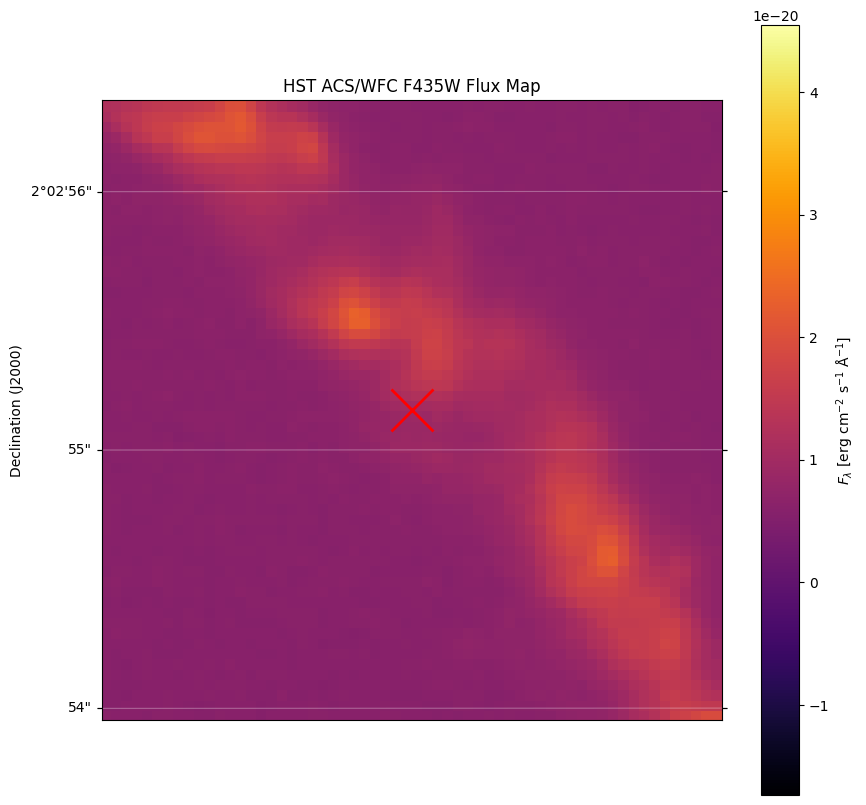

In [12]:
header = hdul['SCI'].header # same WCS info as hdul['WHT'].header ++++ PHOTFLAM!!!!
photflam = header['PHOTFLAM']
wcs = WCS(header)

ra_val = 187.274535
dec_val = 2.048654
px, py = wcs.world_to_pixel_values(ra_val, dec_val)


plot_flux_region(
    hdul,
    x_min=px-30,
    x_max=px+30,
    y_min=py-30,
    y_max=py+30,
    x_cross = px,
    y_cross = py
)

### Computation: 

In [80]:
from astropy.wcs import WCS

def get_flux_and_error_at_coords(hdul, ra, dec): # GEMINI function
    """
    Computes the flux and error at a specific RA and Dec.
    
    Parameters:
    hdul (fits.HDUList): The open FITS file object.
    ra (float): Right Ascension in degrees.
    dec (float): Declination in degrees.
    
    Returns:
    tuple: (flux, error) in units of erg/cm2/s/Angstrom.
    """
    # 1. Access the Science (SCI) and Weight (WHT) extensions
    sci_data = hdul['SCI'].data # hdul[1] == hdul['SCI']
    wht_data = hdul['WHT'].data
    header = hdul['SCI'].header # same WCS info as hdul['WHT'].header ++++ PHOTFLAM!!!!
    
    # 2. Get photometric keyword for flux conversion
    # PHOTFLAM is the inverse sensitivity (erg/cm2/s/A per e-/s)
    photflam = header['PHOTFLAM']
    
    # 3. Initialize WCS and convert RA/Dec to pixel coordinates
    wcs = WCS(header)
    # world_to_pixel returns (x, y) coordinates
    px, py = wcs.world_to_pixel_values(ra, dec)
    
    # Round to nearest integer to find the specific pixel index
    ix, iy = int(np.round(px)), int(np.round(py))
    
    # 4. Extract data at the pixel location
    # Note: numpy uses (y, x) indexing for 2D arrays
    counts_per_sec = sci_data[iy, ix]
    weight = wht_data[iy, ix]
    
    # 5. Calculate Flux and Error
    # Flux = Counts/sec * PHOTFLAM
    flux = counts_per_sec * photflam
    
    # Single pixel error = 1 / sqrt(WHT) converted to flux units
    # Since WHT = 1/sigma^2
    error_counts = 1.0 / np.sqrt(weight)
    error_flux = error_counts * photflam
    
    return flux, error_flux, header['PHOTPLAM'] # units: erg cm–2 sec–1 Å–1 (fluxes) // Å (pivot wavelength)

In [84]:
ra_val = 187.274535
dec_val = 2.048654
flux, error_flux, pivot_wavelength = get_flux_and_error_at_coords(hdul, ra_val, dec_val)

print(f"flux = {flux} +- {error_flux} erg cm–2 sec–1 Å–1 \n Pivot wavelength = {pivot_wavelength} Å ")

flux = 1.0303780147028191e-20 +- 1.0162803407879545e-21 erg cm–2 sec–1 Å–1 
 Pivot wavelength = 5921.8916 Å 


# Big-Scale Integration: 

## Main Implementation

Summary of Implementation:
- Best Observation: The get_best_observation function uses np.argmax on the exposure_duration column of the cone_search_criteria results to find the most significant observation for each filter.
- Flux and Error: Computations use PHOTFLAM for scaling and WHT for noise estimation, as defined in your "Individual Analysis" procedure.
- Traceability: Every major event (searching, selecting, downloading, and computing) is appended to hst_analysis_log.txt via the log_step function.
- Data Storage: The run_hst_analysis function compiles results into a pandas DataFrame and automatically exports it as a CSV file (hst_sed_table.csv) to facilitate your final SED plotting.    

In [13]:
import numpy as np
import os
import glob
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from astropy import coordinates
import astropy.units as u
from astroquery.esa.hubble import ESAHubble

In [18]:
def get_best_observation(c, filter_name, instrument='ACS/WFC'):
    """
    Finds the observation with the largest exposure duration for a given filter.
    Based on notebook sections 2.1 and source
    """
    log_step(f"Searching for observations with filter: {filter_name}...")
    
    # Cone search using user-defined parameters [cite: 7, 147]
    result = esahubble.cone_search_criteria(
        coordinates=c,
        radius=0.475*u.arcmin,
        obs_collection=['HST'],
        data_product_type='image',
        instrument_name=[instrument],
        filters=[filter_name],
        output_format="votable"
    )
    
    if len(result) == 0:
        log_step(f"No results found for filter {filter_name}.")
        return None
        
    log_step(f"Retrieved {len(result)} results. Identifying maximum exposure duration...")
    
    # Logic to select the longest exposure [cite: 8, 161]
    row_idx = np.argmax(result['exposure_duration'])
    max_row = result[row_idx]
    obs_id = max_row['observation_id']
    max_exp = max_row['exposure_duration']
    
    log_step(f"Selected Observation ID: {obs_id} (Exposure: {max_exp}s)")
    return obs_id

In [15]:
def process_observation(obs_id, ra, dec, filter_name):
    """
    Downloads the FITS file, extracts SCI/WHT data, and computes flux/error.
    Based on source [cite: 28, 29] and code logic for flux conversion.
    """
    log_step(f"Downloading FITS files for: {obs_id}...")
    esahubble.download_fits_files(observation_id=obs_id)
    
    # Locate the most recently downloaded FITS file 
    fits_files = glob.glob('*.fits') + glob.glob('*.fits.gz')
    if not fits_files:
        log_step("Error: No FITS files found in directory.")
        return None
    latest_file = max(fits_files, key=os.path.getctime)
    
    log_step(f"Processing file: {latest_file}")
    
    with fits.open(latest_file) as hdul:
        # Extract data from SCI and WHT extensions 
        sci_data = hdul['SCI'].data
        wht_data = hdul['WHT'].data
        header = hdul['SCI'].header
        
        # Photometric keywords for flux conversion
        photflam = header['PHOTFLAM'] # Inverse sensitivity (erg/cm2/s/A per e-/s)
        photplam = header['PHOTPLAM'] # Pivot wavelength (Angstroms)
        
        # Convert RA/Dec to pixel coordinates using WCS
        wcs = WCS(header)
        px, py = wcs.world_to_pixel_values(ra, dec)
        ix, iy = int(np.round(px)), int(np.round(py))
        
        # Extract counts and weight at the specific pixel
        counts_per_sec = sci_data[iy, ix]
        weight = wht_data[iy, ix]
        
        # Calculate Flux and Error
        # Flux = Counts/sec * PHOTFLAM
        # Error = (1 / sqrt(WHT)) * PHOTFLAM
        flux = counts_per_sec * photflam
        error_flux = (1.0 / np.sqrt(weight)) * photflam
        
        log_step(f"Result for {filter_name}: Flux={flux:.2e}, Error={error_flux:.2e}, Pivot={photplam}")
        
        return {
            'Filter': filter_name,
            'Pivot_Wavelength_A': photplam,
            'Flux_erg_cm2_s_A': flux,
            'Error_Flux': error_flux,
            'Observation_ID': obs_id
        }

In [20]:
# Initialize the Hubble Archive interface
esahubble = ESAHubble()

def log_step(message, filename="hst_analysis_log.txt"):
    """Writes the current processing step to a text file for traceability."""
    with open(filename, "a") as f:
        f.write(message + "\n")
    print(message)

In [21]:
def run_hst_analysis(ra, dec, filter_list, instrument='ACS/WFC', output_csv="hst_sed_table.csv"):
    """
    Unified function to iterate through filters and compile the final dataset.
    Writes a CSV file and returns a DataFrame.
    """
    log_step(f"--- Starting Full Analysis for RA={ra}, Dec={dec} ---")
    c = coordinates.SkyCoord(ra=ra, dec=dec, unit='deg', frame='icrs') # [cite: 5]
    dataset = []
    
    for f in filter_list:
        log_step(f"\n--- Processing Filter: {f} ---")
        obs_id = get_best_observation(c, f, instrument)
        
        if obs_id:
            row_data = process_observation(obs_id, ra, dec, f)
            if row_data:
                dataset.append(row_data)
        else:
            log_step(f"Skipping filter {f} (no observations found).")
            
    # Create final table and save to computer
    df = pd.DataFrame(dataset)
    df.to_csv(output_csv, index=False)
    log_step(f"--- Analysis Complete. Data saved to {output_csv} ---")
    
    return df

## Example Usage: 

In [22]:
# Example Usage:
target_ra, target_dec = 187.274535, 2.048654
filters_to_check = ['F606W', 'F814W', 'F435W']
sed_data = run_hst_analysis(target_ra, target_dec, filters_to_check)

--- Starting Full Analysis for RA=187.274535, Dec=2.048654 ---
--- Processing Filter: F606W ---
Searching for observations with filter: F606W...
Retrieved 69 results. Identifying maximum exposure duration...
Selected Observation ID: hst_skycell-p1369x14y11_acs_wfc_f606w_all (Exposure: 9416.0s)
Processing file: hst_skycell-p1369x14y11_acs_wfc_f606w_all_drc.fits.gz
Result for F606W: Flux=1.03e-20, Error=1.02e-21, Pivot=5921.8916
--- Processing Filter: F814W ---
Searching for observations with filter: F814W...
No results found for filter F814W.
Skipping filter F814W (no observations found).
--- Processing Filter: F435W ---
Searching for observations with filter: F435W...
Retrieved 12 results. Identifying maximum exposure duration...
Selected Observation ID: hst_9294_03_acs_wfc_f435w_j8ea03 (Exposure: 1821.0s)
Processing file: hst_9294_03_acs_wfc_f435w_j8ea03_drz.fits.gz
Result for F435W: Flux=3.45e-20, Error=7.39e-21, Pivot=4329.1694
--- Analysis Complete. Data saved to hst_sed_table.csv 

## Plotting

In [24]:
import matplotlib.pyplot as plt

def plot_hst_sed(dataset, log_filename="hst_analysis_log.txt"):
    """
    Plots the Spectral Energy Distribution (SED) from the retrieved HST data.
    
    Parameters:
    dataset (pd.DataFrame or list): The data containing 'Pivot_Wavelength_A', 
                                    'Flux_erg_cm2_s_A', and 'Error_Flux'.
    """
    with open(log_filename, "a") as log:
        log.write("Step: Initiating SED plot generation.\n")
    
    # Convert to DataFrame if it's a list for easier manipulation
    if isinstance(dataset, list):
        df = pd.DataFrame(dataset)
    else:
        df = dataset

    if df.empty:
        with open(log_filename, "a") as log:
            log.write("Warning: Dataset is empty. Plotting cancelled.\n")
        return

    # Sort by wavelength for a continuous line plot 
    df = df.sort_values('Pivot_Wavelength_A')

    plt.figure(figsize=(10, 6))
    
    # Plotting flux vs pivot wavelength with error bars 
    plt.errorbar(
        df['Pivot_Wavelength_A'], 
        df['Flux_erg_cm2_s_A'], 
        yerr=df['Error_Flux'], 
        fmt='o-', 
        capsize=5, 
        color='black', 
        markerfacecolor='blue', 
        label='HST Data'
    )

    # Annotate points with filter names for clarity
    for _, row in df.iterrows():
        plt.annotate(row['Filter'], (row['Pivot_Wavelength_A'], row['Flux_erg_cm2_s_A']),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

    # Log-log scale is standard for SED analysis
    plt.xscale('log')
    plt.yscale('log')
    
    plt.xlabel(r'Pivot Wavelength ($\AA$)')
    plt.ylabel(r'Flux ($erg \cdot cm^{-2} \cdot s^{-1} \cdot \AA^{-1}$)')
    plt.title('HST Multi-Filter Spectral Energy Distribution')
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend()
    
    # Save the plot and log the success
    output_plot = "hst_sed_plot.png"
    plt.savefig(output_plot)
    with open(log_filename, "a") as log:
        log.write(f"Step: SED plot saved to computer as {output_plot}.\n")
    
    plt.show()

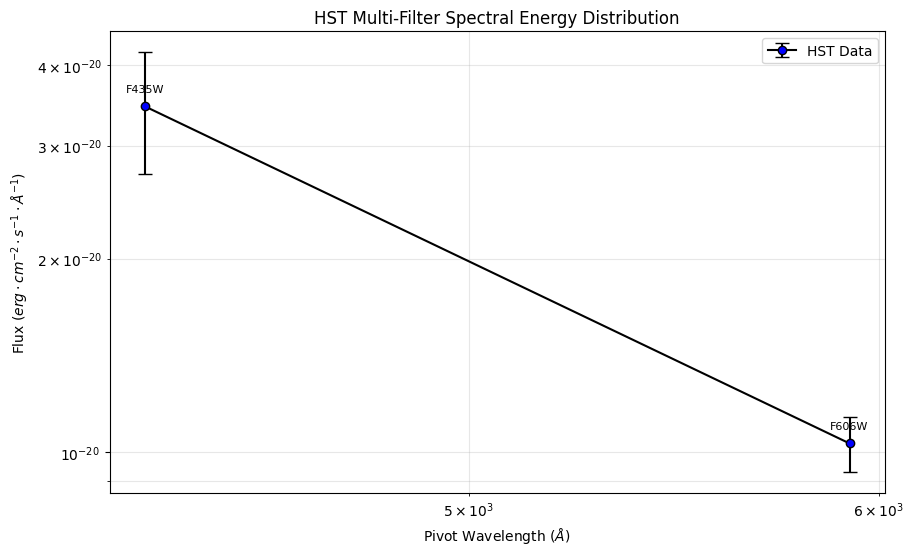

In [26]:
plot_hst_sed(sed_data, log_filename="hst_analysis_log.txt")

## Determining Filters: 

In [35]:
def discover_available_filters(c, radius=0.5*u.arcmin, instrument='ACS/WFC'):
    """
    Queries the archive to see which filters actually have data at this location.
    Using async_job=False to avoid 401 Authentication errors.
    """
    log_step(f"Discovering all available HST images for RA: {c.ra.deg}, Dec: {c.dec.deg}")
    
    try:
        # We set async_job=False to run a synchronous query
        result = esahubble.cone_search_criteria(
            coordinates=c,
            radius=radius,
            obs_collection=['HST'],
            instrument_name=[instrument], # Corrected argument name
            data_product_type='image',
            async_job=False,  # <--- CRITICAL FIX
            output_format="votable"
        )
    except Exception as e:
        log_step(f"Error during discovery search: {e}")
        return []
    
    if result is None or len(result) == 0:
        log_step("No HST data found at these coordinates.")
        return []
    
    # Extract unique filters
    available_filters = list(np.unique(result['filter']))
    log_step(f"Found data for filters: {available_filters}")
    
    return available_filters

In [36]:
target_ra = 187.274535
target_dec = 2.048654
c = coordinates.SkyCoord(ra=target_ra, dec=target_dec, unit='deg', frame='icrs')
discover_available_filters(c)

Discovering all available HST images for RA: 187.274535, Dec: 2.048654
Found data for filters: ['F435W', 'F606W', 'F850LP', 'FR601N', 'FR782N', 'detection']


['F435W', 'F606W', 'F850LP', 'FR601N', 'FR782N', 'detection']

This should allow us to do a smart running with only these filters:

In [32]:
def run_intelligent_hst_analysis(ra, dec):
    c = coordinates.SkyCoord(ra=ra, dec=dec, unit='deg', frame='icrs')
    
    # Step 1: Find out what's actually there
    found_filters = discover_available_filters(c)
    
    if not found_filters:
        return None
    
    # Step 2: Run your existing logic only on filters we KNOW exist
    # Note: We remove the instrument constraint to get WFC3, ACS, etc.
    dataset = []
    for f in found_filters:
        log_step(f"--- Processing Found Filter: {f} ---")
        # Call your existing get_best_observation, but maybe remove instrument=['ACS/WFC']
        obs_id = get_best_observation(c, f, instrument=None) 
        
        if obs_id:
            row_data = process_observation(obs_id, ra, dec, f)
            if row_data:
                dataset.append(row_data)
                
    df = pd.DataFrame(dataset)
    df.to_csv("hst_discovered_sed.csv", index=False)
    return df

Yet, we start with a case-to-case basis to see if they work out correctly. 

Also, we improve the process_observation function to account for multiple downloads in some cases: 

In [ ]:
import time
import requests

def process_observation(obs_id, ra, dec, filter_name):
    """
    Downloads the FITS file with retry logic and specific selection for 'drz' science files.
    """
    log_step(f"Downloading FITS files for: {obs_id}...")
    
    max_retries = 3
    success = False
    for attempt in range(max_retries):
        try:
            esahubble.download_fits_files(observation_id=obs_id)
            success = True
            break
        except (requests.exceptions.ChunkedEncodingError, Exception) as e:
            log_step(f"Download attempt {attempt + 1} failed: {e}. Retrying...")
            time.sleep(5)
    
    if not success:
        log_step(f"Error: Failed to download {obs_id} after {max_retries} attempts.")
        return None

    # --- UPDATED FILE SELECTION LOGIC ---
    # 1. Get all fits files in the current directory
    all_fits = glob.glob('*.fits') + glob.glob('*.fits.gz')
    
    # 2. Filter for files that belong to THIS observation AND are science products (drz or drc)
    # We exclude 'trl', 'log', and 'asn' files which don't contain image data
    science_files = [
        f for f in all_fits 
        if obs_id in f and any(ext in f for ext in ['drz', 'drc'])
    ]
    
    if not science_files:
        # Fallback: if no drz/drc found, try to find any file with 'SCI' extension inside
        # by checking the most recent file that isn't a trailer/log
        log_step(f"Warning: No 'drz' or 'drc' file found for {obs_id}. Checking alternatives...")
        science_files = [f for f in all_fits if obs_id in f and '_trl' not in f and '_log' not in f]

    if not science_files:
        log_step(f"Error: No valid science FITS files found for {obs_id}.")
        return None

    # Pick the most recent valid science file
    latest_file = max(science_files, key=os.path.getctime)
    log_step(f"Processing science file: {latest_file}")
    # ------------------------------------

    try:
        with fits.open(latest_file) as hdul:
            # Verify extensions exist before accessing
            if 'SCI' not in hdul:
                log_step(f"Error: 'SCI' extension not found in {latest_file}. HDUs present: {hdul.info()}")
                return None
            
            sci_data = hdul['SCI'].data
            wht_data = hdul['WHT'].data
            header = hdul['SCI'].header
            
            photflam = header['PHOTFLAM']
            photplam = header['PHOTPLAM']
            
            wcs = WCS(header)
            px, py = wcs.world_to_pixel_values(ra, dec)
            ix, iy = int(np.round(px)), int(np.round(py))
            
            # Check bounds
            if iy >= sci_data.shape[0] or ix >= sci_data.shape[1] or iy < 0 or ix < 0:
                log_step(f"Error: Coordinates outside image bounds for {filter_name}.")
                return None

            counts_per_sec = sci_data[iy, ix]
            weight = wht_data[iy, ix]
            
            if weight <= 0:
                log_step(f"Warning: Zero weight at target location in {filter_name}.")
                return None

            flux = counts_per_sec * photflam
            error_flux = (1.0 / np.sqrt(weight)) * photflam
            
            log_step(f"Result for {filter_name}: Flux={flux:.2e}, Error={error_flux:.2e}, Pivot={photplam}")
            
            return {
                'Filter': filter_name,
                'Pivot_Wavelength_A': photplam,
                'Flux_erg_cm2_s_A': flux,
                'Error_Flux': error_flux,
                'Observation_ID': obs_id
            }
    except Exception as e:
        log_step(f"Error processing {latest_file}: {e}")
        return None

## SED Plotting erg-scale

In [42]:
import pandas as pd

df = pd.read_csv('2.5.Large-Scale_Application/hst_sed_table.csv')
#print(df.head()) # Prints the first 5 rows

In [45]:
df

,Filter,Pivot_Wavelength_A,Flux_erg_cm2_s_A,Error_Flux,Observation_ID
0,F435W,4329.1694,3.451788e-20,7.386377e-21,hst_9294_03_acs_wfc_f435w_j8ea03
1,F606W,5921.8916,1.030378e-20,1.016280e-21,hst_skycell-p1369x14y11_acs_wfc_f606w_all
2,F850LP,9034.4863,2.136400e-20,3.669085e-21,hst_9294_03_acs_wfc_f850lp_j8ea03


In [49]:
wavelengths = df['Pivot_Wavelength_A']
flux = df['Flux_erg_cm2_s_A']
err_flux = df['Error_Flux']

In [50]:
c = 3e18 # Speed of light in Angstroms/second (approx)
# 1. Calculate Frequency (nu)
# Using wavelengths in Angstroms to get frequency in Hz
nu = c / wavelengths

# 2. Calculate nu*Fnu
# Since nu*Fnu = lambda*Flambda, we multiply wavelengths (A) by flux (erg/cm2/s/A)
nu_fnu = wavelengths * flux
err_nu_fnu = wavelengths * err_flux # Propagate error linearly

# 3. Take the Logarithms
log_nu = np.log10(nu)
log_nu_fnu = np.log10(nu_fnu)

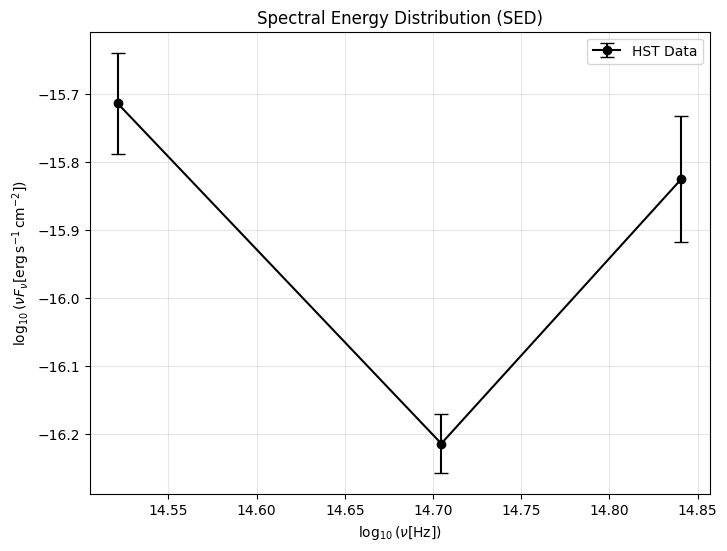

In [51]:

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.errorbar(log_nu, log_nu_fnu, 
             yerr=err_nu_fnu / (nu_fnu * np.log(10)), # Error propagation for log10
             fmt='o', capsize=5, linestyle='-', color='black', label='HST Data')

plt.xlabel(r'$\log_{10}(\nu \mathrm{[Hz]})$')
plt.ylabel(r'$\log_{10}(\nu F_\nu \mathrm{[erg\, s^{-1}\, cm^{-2}]})$')
plt.title('Spectral Energy Distribution (SED)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()